In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


In [ ]:
 # Librerías necesarias
using ITensors
using ITensorMPS
using Plots
using LinearAlgebra

In [3]:
# ==========================================================
# Función genérica para seno y coseno analítico mediante Matrices de Rotación (χ = 2)
# ==========================================================
function construir_trigonometrica_rotacion(sites, x_min,dx, N, k_freq; tipo="cos")
    b = MPS(sites)
    blinks = [Index(2, "link,l=$i") for i in 1:(N-1)]
    
    # --- SITIO 1: Inyección Inicial con x_min ---
    b[1] = ITensor(sites[1], blinks[1])
    th_min = k_freq * x_min
    th1 = k_freq * dx * 2.0^0

    # s=1 (bit=0 -> No hay rotación extra, se queda en th_min)
    b[1][sites[1]=>1, blinks[1]=>1] = cos(th_min)
    b[1][sites[1]=>1, blinks[1]=>2] = sin(th_min)

    # s=2 (bit=1 -> Rotamos th_min un ángulo th1 extra)
    # Usamos las identidades: cos(A+B) = cosA*cosB - sinA*sinB
    #                        sin(A+B) = sinA*cosB + cosA*sinB
    b[1][sites[1]=>2, blinks[1]=>1] = cos(th_min + th1)
    b[1][sites[1]=>2, blinks[1]=>2] = sin(th_min + th1)

    # --- BULK: Sitios 2 a N-1 (Matrices de Rotación) ---
    for k in 2:(N-1)
        b[k] = ITensor(blinks[k-1], sites[k], blinks[k])
        th = k_freq * dx * 2.0^(k-1)
        
        # s=1 (bit=0): Matriz Identidad Virtual
        b[k][blinks[k-1]=>1, sites[k]=>1, blinks[k]=>1] = 1.0
        b[k][blinks[k-1]=>2, sites[k]=>1, blinks[k]=>2] = 1.0
        
        # s=2 (bit=1): Matriz de Rotación Horaria/Antihoraria
        b[k][blinks[k-1]=>1, sites[k]=>2, blinks[k]=>1] = cos(th)
        b[k][blinks[k-1]=>1, sites[k]=>2, blinks[k]=>2] = sin(th)
        b[k][blinks[k-1]=>2, sites[k]=>2, blinks[k]=>1] = -sin(th)
        b[k][blinks[k-1]=>2, sites[k]=>2, blinks[k]=>2] = cos(th)
    end

    # --- SITIO N: Cierre y Extracción del Coseno ---
    b[N] = ITensor(blinks[N-1], sites[N])
    thN = k_freq * dx * 2.0^(N-1)
    
    if tipo == "cos"
        # Extrae Canal 1 (Multiplica por c = [1, 0]^T)
        b[N][blinks[N-1]=>1, sites[N]=>1] = 1.0
        b[N][blinks[N-1]=>2, sites[N]=>1] = 0.0
        
        b[N][blinks[N-1]=>1, sites[N]=>2] = cos(thN)
        b[N][blinks[N-1]=>2, sites[N]=>2] = -sin(thN)
    elseif tipo == "sin"
        # Extrae Canal 2 (Multiplica por c = [0, 1]^T)
        b[N][blinks[N-1]=>1, sites[N]=>1] = 0.0
        b[N][blinks[N-1]=>2, sites[N]=>1] = 1.0
        
        b[N][blinks[N-1]=>1, sites[N]=>2] = sin(thN)
        b[N][blinks[N-1]=>2, sites[N]=>2] = cos(thN)
    end
    
    return b
end

construir_trigonometrica_rotacion (generic function with 1 method)

In [9]:
# --- PARÁMETROS DE LA MALLA ---
N = 20                  # 20 bits
dim_total = 1 << N      # 1024 puntos
x_min = 0.0
x_max = 2 * pi          # Escalamos a 2π para que los armónicos completen ciclos limpios
dx = (x_max - x_min) / dim_total  

sites = siteinds("Qubit", N)

# ==========================================================
# GENERACIÓN DIRECTA DE LA SERIE DE FOURIER MEDIANTE MPS
# ==========================================================
println("=== CONSTRUCCIÓN EN ESPACIO DE REDES TENSORIALES ===")
println("Sumando 15 armónicos directamente en la variedad MPS...")

# Inicializamos el contenedor del MPS total
mps_original = nothing
M = 15 # Número de términos

for m in 1:M
    k = 2 * m - 1 # Armónicos impares: 1, 3, 5, ..., 29
    #coef = (4.0 / pi) * (1.0 / k) #Cuadrada
    coef = (8.0 / pi^2) * ((-1.0)^(m-1) / k^2) #Triangular
    
    # Generamos el MPS exacto (χ = 2) para este armónico de tipo seno
    # Nota: Usamos "sinh" debido al nombre del canal en tu función de rotación
    mps_armonico = construir_trigonometrica_rotacion(sites, x_min, dx, N, k; tipo="sin")
    
    # Escalamos linealmente el MPS multiplicándolo por su coeficiente de Fourier
    mps_armonico_escalado = coef * mps_armonico
    
    if isnothing(mps_original)
        mps_original = mps_armonico_escalado
    else
        # Suma directa en el espacio MPS: ITensors combina los bloques virtuales automáticamente
        mps_original = mps_original + mps_armonico_escalado
    end
end

# ==========================================================
# COMPRESIÓN SVD CON DIFERENTES TOLERANCIAS (CUTOFF)
# ==========================================================
println("\n=== EXPERIMENTO DE COMPRESIÓN SVD EN FOURIER ===")
println("Dimensión de la malla implícita: ", dim_total, " puntos.")
println("Bond Dimension original del MPS sumado (máximo teórico): ", maxlinkdim(mps_original))
println("-"^60)

# Caso 1: Compresión Ultra-Estricta
mps_estricto = copy(mps_original)
truncate!(mps_estricto; cutoff=1e-14)
println("SVD con cutoff = 1e-14 (Precisión total) -> Max Bond Dim: ", maxlinkdim(mps_estricto))

# Caso 2: Compresión Estándar
mps_estandar = copy(mps_original)
truncate!(mps_estandar; cutoff=1e-8)
println("SVD con cutoff = 1e-8  (Física estándar) -> Max Bond Dim: ", maxlinkdim(mps_estandar))

# Caso 3: Compresión Agresiva
mps_agresivo = copy(mps_original)
truncate!(mps_agresivo; cutoff=1e-4)
println("SVD con cutoff = 1e-4  (Alta compresión) -> Max Bond Dim: ", maxlinkdim(mps_agresivo))

# ==========================================================
# MEDICIÓN DEL ERROR DE LA COMPRESIÓN AGRESIVA
# ==========================================================
norma_orig = norm(mps_original)
norma_agres = norm(mps_agresivo)
solapamiento = inner(mps_original, mps_agresivo)

distancia = sqrt(max(0.0, norma_orig^2 + norma_agres^2 - 2 * real(solapamiento)))

println("-"^60)
println("Error global cometido por la compresión agresiva: ", distancia)
# ==========================================================
# CÁLCULO DEL ERROR RELATIVO
# ==========================================================
error_relativo = (distancia / norma_orig) * 100

println("Norma del vector original (espacio L2): ", norma_orig)
println("Error RELATIVO real de la compresión:   ", error_relativo, " %")

=== CONSTRUCCIÓN EN ESPACIO DE REDES TENSORIALES ===
Sumando 15 armónicos directamente en la variedad MPS...

=== EXPERIMENTO DE COMPRESIÓN SVD EN FOURIER ===
Dimensión de la malla implícita: 1048576 puntos.
Bond Dimension original del MPS sumado (máximo teórico): 10
------------------------------------------------------------
SVD con cutoff = 1e-14 (Precisión total) -> Max Bond Dim: 8
SVD con cutoff = 1e-8  (Física estándar) -> Max Bond Dim: 5
SVD con cutoff = 1e-4  (Alta compresión) -> Max Bond Dim: 2
------------------------------------------------------------
Error global cometido por la compresión agresiva: 4.698093055749052
Norma del vector original (espacio L2): 591.2048813120518
Error RELATIVO real de la compresión:   0.7946641180165236 %


Muestreando los MPS comprimidos en 2002 puntos...


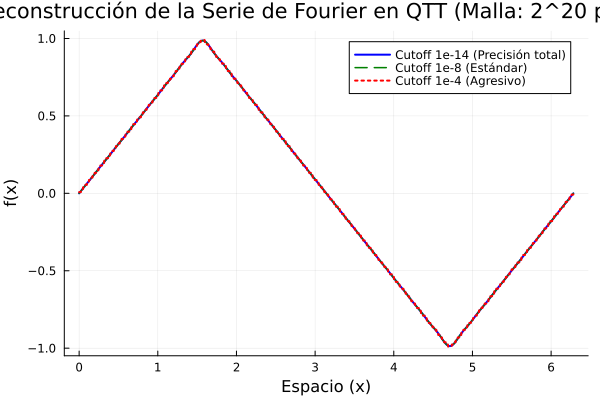

In [11]:
using Plots

# ==========================================================
# FUNCIÓN PARA EVALUAR EL MPS EN UN ÍNDICE
# ==========================================================
# Contrae la cadena MPS fijando los bits correspondientes al índice 'idx'
function evaluar_mps_en_punto(mps, sites, indice_físico)
    N = length(mps)
    
    # Evaluamos el primer sitio (bit menos significativo)
    bit = (indice_físico & 1) + 1
    p = ITensor(sites[1])
    p[sites[1] => bit] = 1.0
    entorno = mps[1] * p  # Deja solo el enlace virtual derecho
    
    # Contraemos secuencialmente el resto de la cadena
    for k in 2:N
        bit = ((indice_físico >> (k - 1)) & 1) + 1
        p = ITensor(sites[k])
        p[sites[k] => bit] = 1.0
        entorno = entorno * (mps[k] * p)
    end
    
    return real(scalar(entorno))
end

# ==========================================================
# MUESTREO PARA LA GRÁFICA
# ==========================================================
num_puntos_grafica = 2000
paso = div(dim_total, num_puntos_grafica)

indices_muestreo = 0:paso:(dim_total - 1)
x_vals = [idx * dx for idx in indices_muestreo]

println("Muestreando los MPS comprimidos en $(length(x_vals)) puntos...")

# Evaluamos los tres estados comprimidos en la selección de puntos
y_estricto = [evaluar_mps_en_punto(mps_estricto, sites, idx) for idx in indices_muestreo]
y_estandar = [evaluar_mps_en_punto(mps_estandar, sites, idx) for idx in indices_muestreo]
y_agresivo = [evaluar_mps_en_punto(mps_agresivo, sites, idx) for idx in indices_muestreo]

# ==========================================================
# GENERACIÓN DE LA VISUALIZACIÓN
# ==========================================================
plot(x_vals, y_estricto, label="Cutoff 1e-14 (Precisión total)", linewidth=2, color=:blue, grid=true)
plot!(x_vals, y_estandar, label="Cutoff 1e-8 (Estándar)", linewidth=1.5, linestyle=:dash, color=:green)
plot!(x_vals, y_agresivo, label="Cutoff 1e-4 (Agresivo)", linewidth=2, linestyle=:dot, color=:red)

title!("Reconstrucción de la Serie de Fourier en QTT (Malla: 2^$N puntos)")
xlabel!("Espacio (x)")
ylabel!("f(x)")